In [1]:
import scanpy as sc
import pandas as pd
import scvi

In [2]:
# https://figshare.com/ndownloader/files/24539942
anndata = sc.read_h5ad("data/Lung_atlas_public.h5ad")
anndata

AnnData object with n_obs × n_vars = 32472 × 15148
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    layers: 'counts'

In [3]:
anndata.raw = anndata  # keep full dimension safe
sc.pp.highly_variable_genes(
    anndata,
    flavor="seurat_v3",
    n_top_genes=2000,
    layer="counts",
    batch_key="batch",
    subset=True,
)
anndata

/anaconda3/envs/bibola/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg'
    layers: 'counts'

In [4]:
anndata.obs.groupby("cell_type").size()

/tmp/ipykernel_1260340/3276086893.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  anndata.obs.groupby("cell_type").size()


cell_type
B cell                  1353
Basal 1                 1972
Basal 2                 3072
Ciliated                3155
Dendritic cell          1367
Endothelium              988
Fibroblast               733
Ionocytes                 46
Lymphatic                341
Macrophage              7492
Mast cell                889
Neutrophil_CD14_high    1626
Neutrophils_IL1R2        472
Secretory               2459
T/NK cell               1797
Type 1                   424
Type 2                  4286
dtype: int64

In [5]:
anndata.obs

,dataset,location,nGene,nUMI,patientGroup,percent.mito,protocol,sanger_type,size_factors,sampling_method,batch,cell_type,donor
index,,,,,,,,,,,,,
GAGGGGCCAGCC,Dropseq_transplant,Dropseq_lower,249,355,nan,0.019718,drop-seq,drop-seq,0.381231,Transplant,B1,Type 2,B1
ACATAGATAGGC,Dropseq_transplant,Dropseq_lower,582,987,nan,0.044580,drop-seq,drop-seq,1.081643,Transplant,B1,Type 2,B1
ATCGACGCGGCA,Dropseq_transplant,Dropseq_lower,292,490,nan,0.026531,drop-seq,drop-seq,0.497352,Transplant,B1,Type 2,B1
CCAGCTTAGGTT,Dropseq_transplant,Dropseq_lower,1057,1806,nan,0.035437,drop-seq,drop-seq,2.172617,Transplant,B1,Type 2,B1
TCATAGAGTCCT,Dropseq_transplant,Dropseq_lower,716,1378,nan,0.020319,drop-seq,drop-seq,1.197578,Transplant,B1,Type 2,B1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
LungTranscriptome7239219_LungTranscriptome7239219GGGCATCCACCAACCG,10x_Transplant,Transplant,1178,3245,Parenchyma,0.011896,10x v2,other,0.775650,Transplant,5,Mast cell,5
LungTranscriptome7239219_LungTranscriptome7239219TGCTGCTAGCAATCTC,10x_Transplant,Transplant,1919,5984,Parenchyma,0.018747,10x v2,other,0.982236,Transplant,5,Mast cell,5
LungTranscriptome7239213_GACTGCGTCCTGCCAT,10x_Transplant,Transplant,4411,25233,Parenchyma,0.010489,10x v2,other,1.235763,Transplant,3,Mast cell,3


In [6]:
sc.pp.pca(anndata)
sc.pp.neighbors(anndata)
sc.tl.umap(anndata)

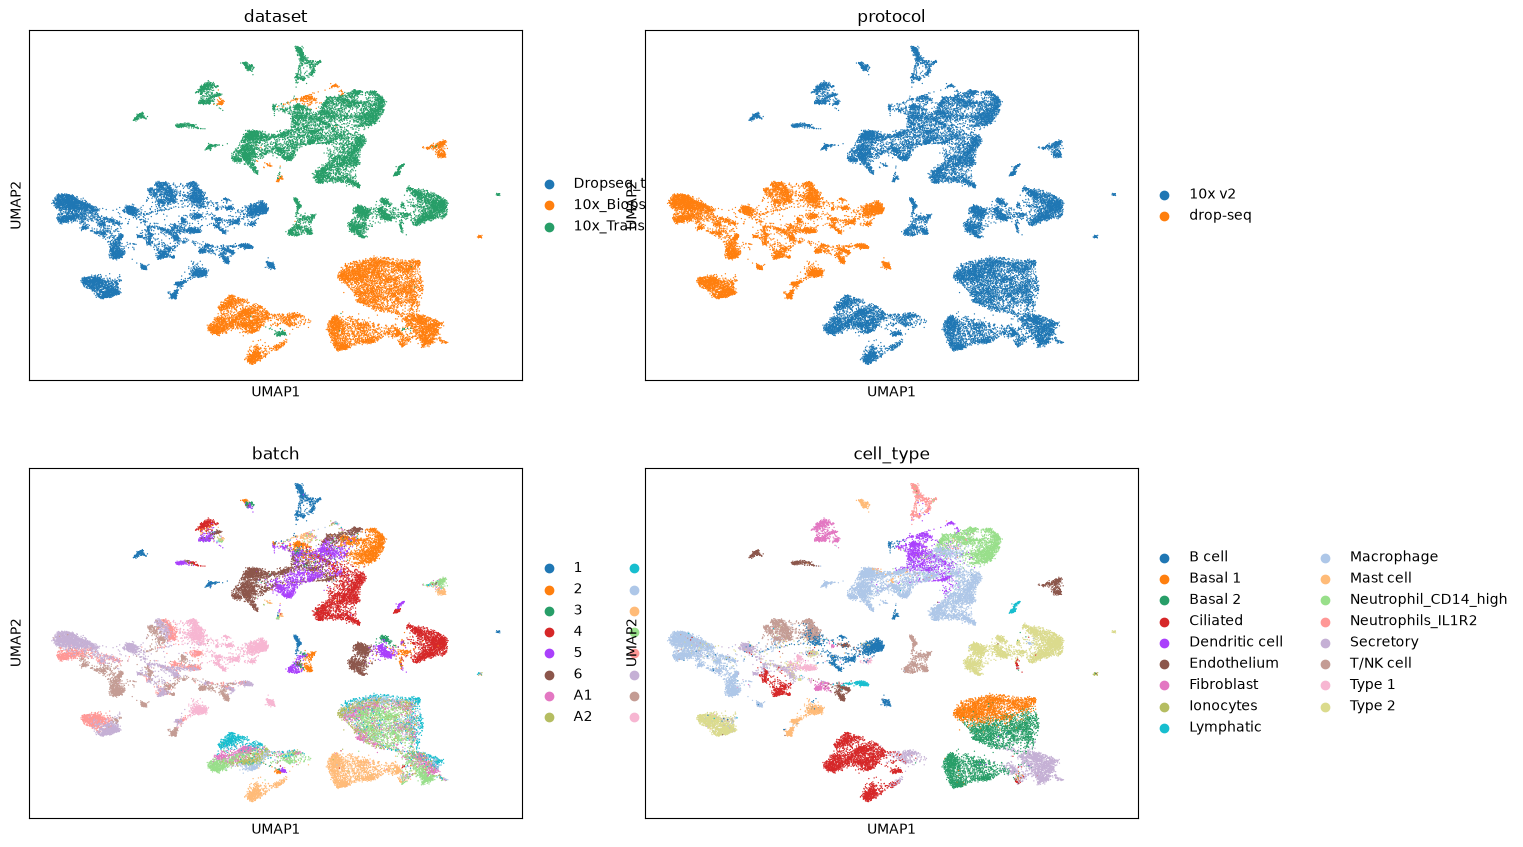

In [7]:
# original UMAP (without batch correction)
sc.pl.umap(anndata, color=["dataset", "protocol", "batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy, ncols=2)

In [8]:
scvi.model.SCVI.setup_anndata(anndata, layer="counts", batch_key="batch")

/anaconda3/envs/bibola/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [9]:
scvi_model = scvi.model.SCVI(anndata, n_layers=2, n_latent=30, gene_likelihood="nb")
scvi_model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [10]:
scvi_model.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/anaconda3/envs/bibola/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLo

Training:   0%|          | 0/246 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=246` reached.


In [11]:
SCVI_LATENT_KEY = "X_scVI"
anndata.obsm[SCVI_LATENT_KEY] = scvi_model.get_latent_representation()
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_umap', 'X_scVI'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [12]:
sc.pp.neighbors(anndata, use_rep=SCVI_LATENT_KEY, key_added="neighbors_scVI")
sc.tl.umap(anndata, neighbors_key="neighbors_scVI", key_added="umap_scVI")

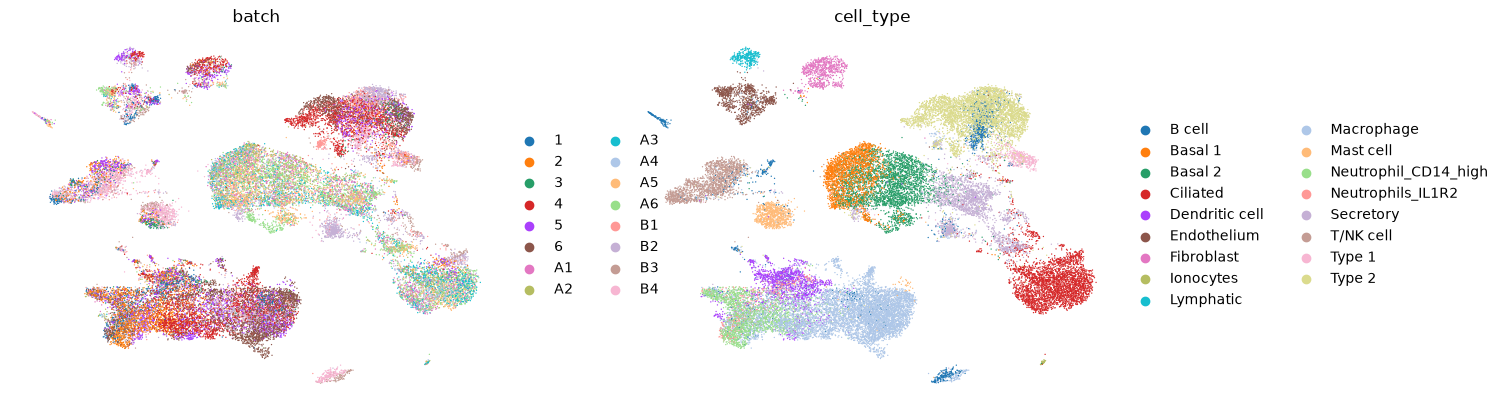

In [13]:
sc.pl.embedding(
    anndata,
    color=["batch", "cell_type"],
    basis="umap_scVI",
    frameon=False,
)

In [14]:
from bibola.model import ChunkIntegration

In [15]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca"].shape[1],
    hidden_channels=[1024,],
    out_channels=30,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-4}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[1024], out_channels=30, optimizer=Adam, not fitted)

In [16]:
batch_correction_model.fit(
    anndata.obsm["X_pca"], anndata.obs[["batch"]], epochs=5, lr=1e-4,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":.25, "topology_loss": .75, "knn_loss": 2.},
    n_chunks=10, verbose=True
)

  chunk 1/10 - total_loss=-0.1711 (abs_lisa_loss=0.0956, topology_loss=-0.6848, knn_loss=-0.0117)
  chunk 2/10 - total_loss=-0.1738 (abs_lisa_loss=0.0914, topology_loss=-0.6884, knn_loss=-0.0140)
  chunk 3/10 - total_loss=-0.1798 (abs_lisa_loss=0.0836, topology_loss=-0.7068, knn_loss=-0.0151)
  chunk 4/10 - total_loss=-0.1776 (abs_lisa_loss=0.0949, topology_loss=-0.7057, knn_loss=-0.0136)
  chunk 5/10 - total_loss=-0.1875 (abs_lisa_loss=0.0731, topology_loss=-0.7186, knn_loss=-0.0210)
  chunk 6/10 - total_loss=-0.1894 (abs_lisa_loss=0.0779, topology_loss=-0.7286, knn_loss=-0.0206)
  chunk 7/10 - total_loss=-0.1917 (abs_lisa_loss=0.0796, topology_loss=-0.7371, knn_loss=-0.0210)
  chunk 8/10 - total_loss=-0.1964 (abs_lisa_loss=0.0718, topology_loss=-0.7433, knn_loss=-0.0248)
  chunk 9/10 - total_loss=-0.2004 (abs_lisa_loss=0.0656, topology_loss=-0.7440, knn_loss=-0.0298)
  chunk 10/10 - total_loss=-0.1995 (abs_lisa_loss=0.0685, topology_loss=-0.7452, knn_loss=-0.0284)
Epoch 1/5 - total_l

In [17]:
batch_correction_model.loss_history

loss                          loss_weights                       
  abs_lisa_loss topology_loss  knn_loss abs_lisa_loss topology_loss knn_loss
0      0.080205     -0.720247 -0.019997          0.25          0.75      2.0
1      0.056086     -0.757925 -0.055895          0.25          0.75      2.0
2      0.040771     -0.741409 -0.140605          0.25          0.75      2.0
3      0.030599     -0.671120 -0.287024          0.25          0.75      2.0
4      0.024220     -0.576335 -0.457710          0.25          0.75      2.0

In [18]:
anndata.obsm["X_corrected"] = batch_correction_model.transform(
    anndata.obsm["X_pca"], anndata.obs[["batch"]]
).detach().numpy()

from sklearn.decomposition import PCA

# we apply PCA to reduce the collinearity after the batch correction.
pca_model = PCA(n_components=batch_correction_model.out_channels)
anndata.obsm["X_corrected"] = pca_model.fit_transform(anndata.obsm["X_corrected"])
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities'

In [19]:
sc.pp.neighbors(anndata, use_rep="X_corrected", key_added="neighbors_corrected")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected", key_added="umap_corrected")
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities'

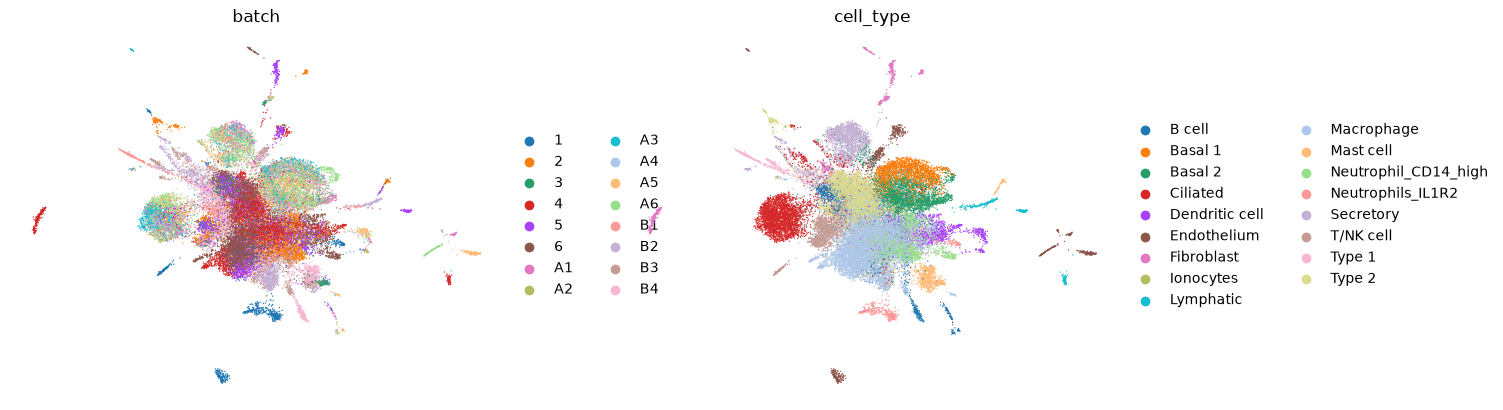

In [20]:
sc.pl.embedding(
    anndata,
    color=["batch", "cell_type"],
    basis="umap_corrected",
    frameon=False,
)
# UMAP after batch correction via bibola

In [21]:
from harmonypy import run_harmony
anndata.obsm["X_pca_harmony"] = run_harmony(anndata.obsm["X_pca"], anndata.obs, ["batch"]).Z_corr
anndata.obsm["X_pca_harmony"]

2026-08-11 18:08:44,855 - harmonypy - INFO - Running Harmony
2026-08-11 18:08:44,855 - harmonypy - INFO -   Parameters:
2026-08-11 18:08:44,855 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-11 18:08:44,856 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-11 18:08:44,856 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-11 18:08:44,856 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-11 18:08:44,856 - harmonypy - INFO -     nclust: 100
2026-08-11 18:08:44,857 - harmonypy - INFO -     block_size: 0.05
2026-08-11 18:08:44,857 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-11 18:08:44,857 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-11 18:08:44,857 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-08-11 18:08:44,858 - harmonypy - INFO -     verbose: True
2026-08-11 18:08:44,858 - harmonypy - INFO -     random_state: 0
2026-08-11 18:08:44,858 - harmonypy - INFO -   Data: 50 PCs × 32472 cells
2026-08-

array([[ 1.65743005,  7.52497435,  0.25517264, ...,  0.11654027,
        -0.53503984, -0.22242148],
       [ 0.88072044,  7.19741344,  0.22153081, ..., -0.32729483,
         0.45369196,  0.82945728],
       [ 0.94033009,  7.96733856,  0.92544198, ..., -0.43930417,
        -0.29741594, -0.41001469],
       ...,
       [ 5.03172207, -4.03623343, -1.80268908, ...,  0.6981867 ,
         0.54427189, -0.55465281],
       [ 4.65386486, -4.91154718, -0.5864678 , ...,  0.91752118,
        -0.1319973 ,  0.12151333],
       [ 5.21427965, -4.02160215, -1.61945224, ...,  1.01830983,
         0.03995328, -0.3437866 ]], shape=(32472, 50))

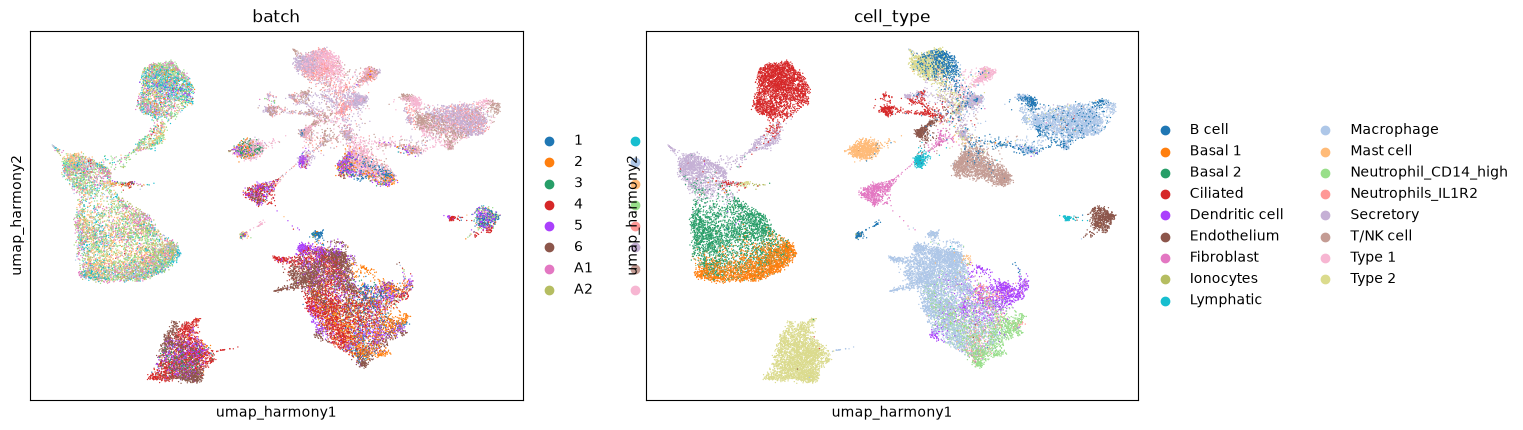

In [22]:
sc.pp.neighbors(anndata, use_rep="X_pca_harmony", key_added="neighbors_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_harmony", key_added="umap_harmony")
sc.pl.embedding(anndata, color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy, basis="umap_harmony")
# UMAP after batch correction via harmony

In [23]:
batch_correction_model = ChunkIntegration(
    in_channels=anndata.obsm["X_pca_harmony"].shape[1],
    hidden_channels=[1024,],
    out_channels=30,
    dropout=0.1,
    optimizer_kwargs={"lr": 1e-4}
)
batch_correction_model

ChunkIntegration(in_channels=50, hidden_channels=[1024], out_channels=30, optimizer=Adam, not fitted)

In [24]:
batch_correction_model.fit(
    anndata.obsm["X_pca_harmony"], anndata.obs[["batch"]], epochs=2, lr=1e-4,
    print_every=1, k_inter=5, k_intra=100, norm=1,
    loss_weights={"abs_lisa_loss":.5, "topology_loss": .25, "knn_loss": .25},
    n_chunks=10, verbose=True
)

  chunk 1/10 - total_loss=-0.1493 (abs_lisa_loss=0.0581, topology_loss=-0.6958, knn_loss=-0.0176)
  chunk 2/10 - total_loss=-0.1500 (abs_lisa_loss=0.0584, topology_loss=-0.6974, knn_loss=-0.0193)
  chunk 3/10 - total_loss=-0.1517 (abs_lisa_loss=0.0530, topology_loss=-0.6920, knn_loss=-0.0208)
  chunk 4/10 - total_loss=-0.1530 (abs_lisa_loss=0.0528, topology_loss=-0.6963, knn_loss=-0.0213)
  chunk 5/10 - total_loss=-0.1544 (abs_lisa_loss=0.0501, topology_loss=-0.6957, knn_loss=-0.0222)
  chunk 6/10 - total_loss=-0.1565 (abs_lisa_loss=0.0476, topology_loss=-0.6959, knn_loss=-0.0254)
  chunk 7/10 - total_loss=-0.1565 (abs_lisa_loss=0.0469, topology_loss=-0.6958, knn_loss=-0.0239)
  chunk 8/10 - total_loss=-0.1637 (abs_lisa_loss=0.0458, topology_loss=-0.7173, knn_loss=-0.0291)
  chunk 9/10 - total_loss=-0.1594 (abs_lisa_loss=0.0430, topology_loss=-0.6925, knn_loss=-0.0311)
  chunk 10/10 - total_loss=-0.1605 (abs_lisa_loss=0.0433, topology_loss=-0.7025, knn_loss=-0.0262)
Epoch 1/2 - total_l

In [25]:
batch_correction_model.loss_history

loss                          loss_weights                       
  abs_lisa_loss topology_loss  knn_loss abs_lisa_loss topology_loss knn_loss
0      0.049907     -0.698118 -0.023695           0.5          0.25     0.25
1      0.036894     -0.724540 -0.044658           0.5          0.25     0.25

In [26]:
anndata.obsm["X_corrected_after_harmony"] = batch_correction_model.transform(
    anndata.obsm["X_pca_harmony"], anndata.obs[["batch"]]
).detach().numpy()

from sklearn.decomposition import PCA

pca_model = PCA(n_components=batch_correction_model.out_channels)
anndata.obsm["X_corrected_after_harmony"] = pca_model.fit_transform(anndata.obsm["X_corrected_after_harmony"])
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_scVI_connectivities', 'neighbors_corrected_distances', 'neighbors_corrected_connectivities', 'neighbors

In [27]:
sc.pp.neighbors(anndata, use_rep="X_corrected_after_harmony", key_added="neighbors_corrected_after_harmony")
sc.tl.umap(anndata, neighbors_key="neighbors_corrected_after_harmony", key_added="umap_corrected_after_harmony")
anndata

AnnData object with n_obs × n_vars = 32472 × 2000
    obs: 'dataset', 'location', 'nGene', 'nUMI', 'patientGroup', 'percent.mito', 'protocol', 'sanger_type', 'size_factors', 'sampling_method', 'batch', 'cell_type', 'donor', '_scvi_batch', '_scvi_labels'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'dataset_colors', 'protocol_colors', 'batch_colors', 'cell_type_colors', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors_scVI', 'umap_scVI', 'neighbors_corrected', 'umap_corrected', 'neighbors_harmony', 'umap_harmony', 'neighbors_corrected_after_harmony', 'umap_corrected_after_harmony'
    obsm: 'X_pca', 'X_umap', 'X_scVI', 'umap_scVI', 'X_corrected', 'umap_corrected', 'X_pca_harmony', 'umap_harmony', 'X_corrected_after_harmony', 'umap_corrected_after_harmony'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'neighbors_scVI_distances', 'neighbors_sc

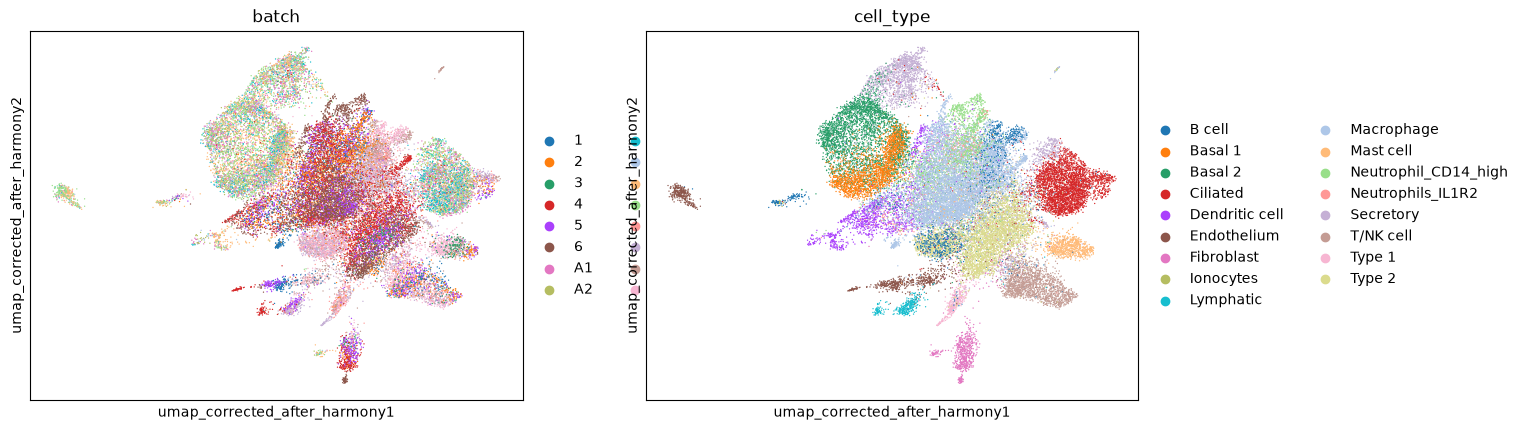

In [28]:
sc.pl.embedding(anndata, basis="umap_corrected_after_harmony", color=["batch", "cell_type"], palette=sc.pl.palettes.vega_20_scanpy)
# UMAP after batch correction via bibola, starting from harmony

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


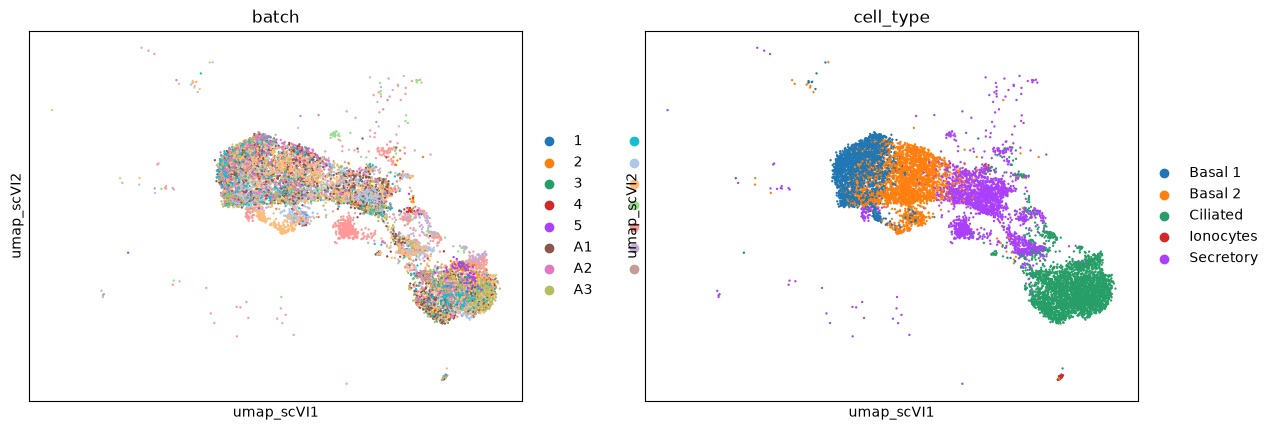

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


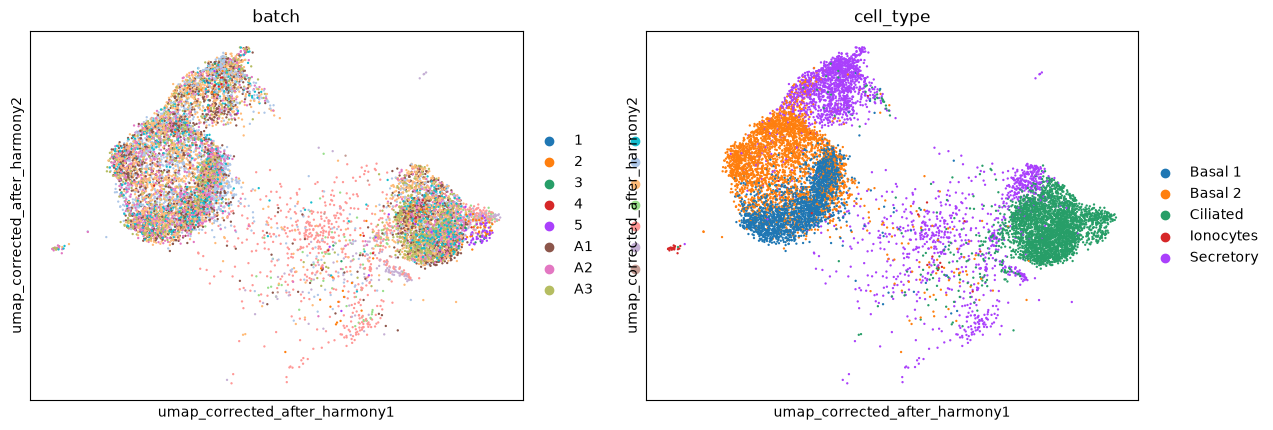

In [29]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Basal 1", "Basal 2", "Secretory", "Ciliated", "Ionocytes"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Basal
# ├── Basal 1
# ├── Basal 2
# │
# ├── Secretory
# │     └── Ciliated
# │
# └── Ionocytes
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


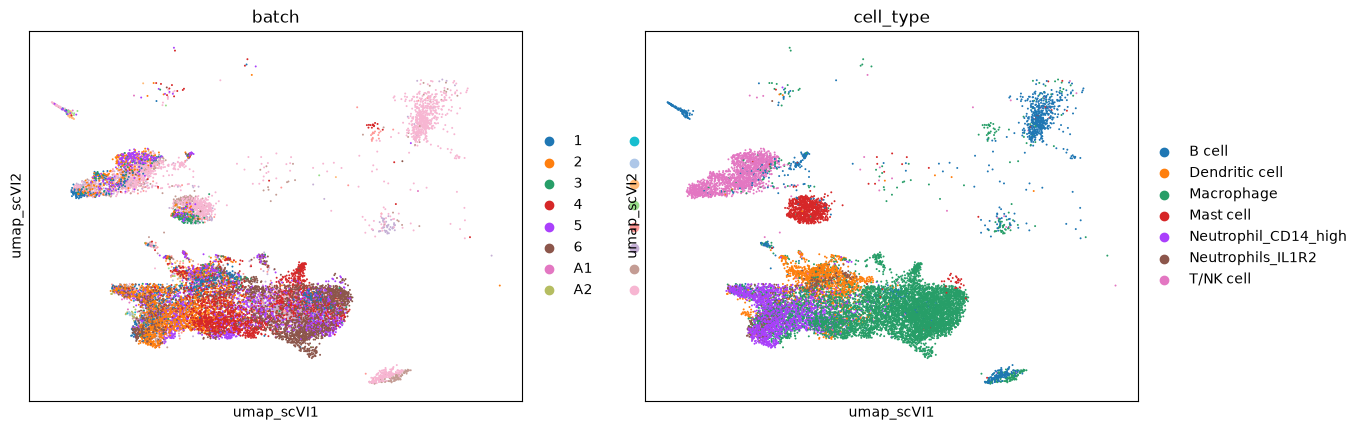

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


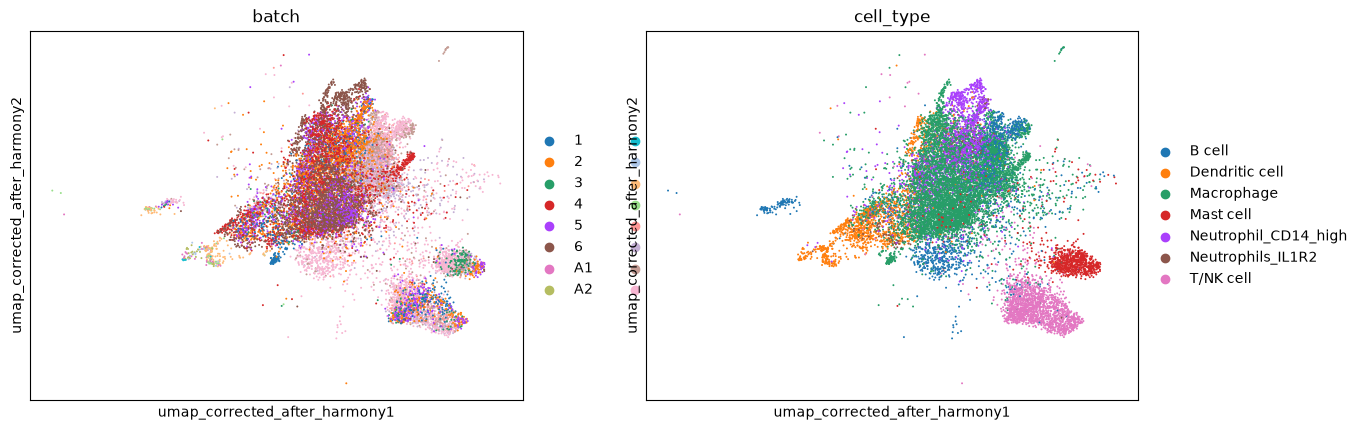

In [30]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["B cell", "T/NK cell", "Neutrophils_IL1R2", "Neutrophil_CD14_high", "Macrophage", "Dendritic cell", "Mast cell"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# HSC
# ├── Lymphoid
# │     ├── B cell
# │     └── T/NK cell
# │
# └── Myeloid
#       ├── Neutrophils_IL1R2
#       ├── Neutrophil_CD14_high
#       ├── Macrophage
#       ├── Dendritic cell
#       └── Mast cell
pass


/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


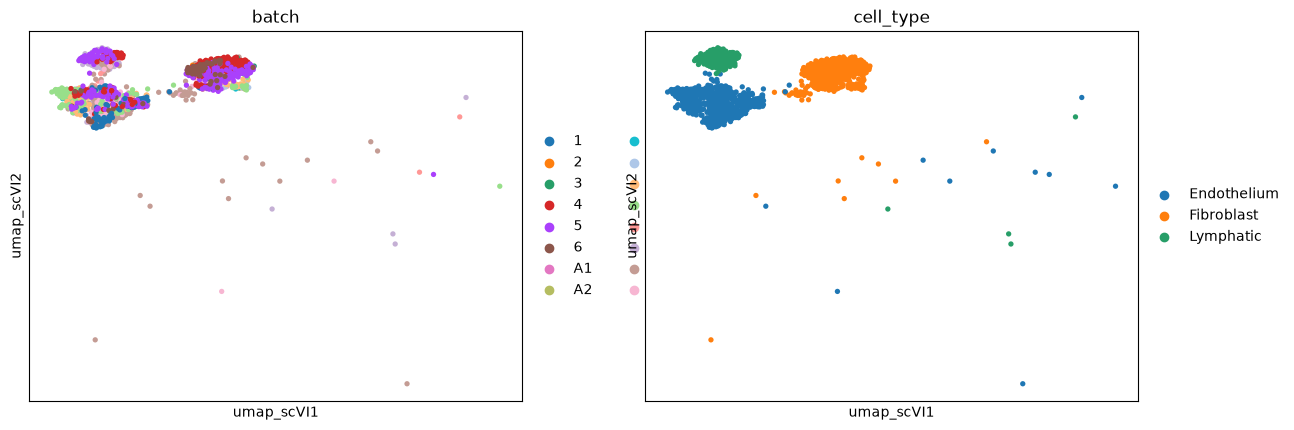

/anaconda3/envs/bibola/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


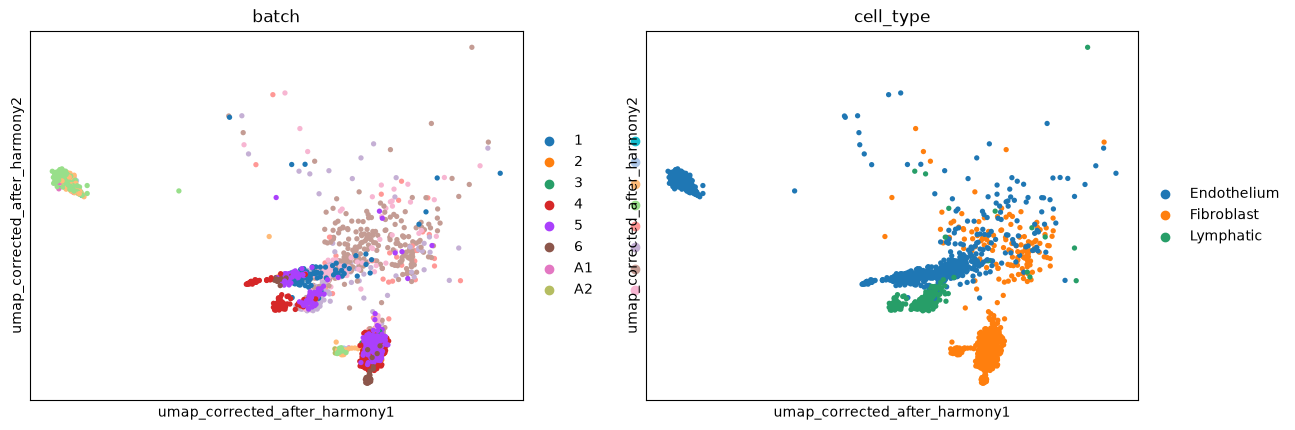

In [31]:
sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_scVI",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

sc.pl.embedding(
    anndata[anndata.obs.cell_type.isin(["Fibroblast", "Endothelium", "Lymphatic"])],
    basis="umap_corrected_after_harmony",
    color=["batch", "cell_type"],
    palette=sc.pl.palettes.vega_20_scanpy
)

# Mesenchymal progenitor
#       └── Fibroblast

# Endothelial progenitor
#       ├── Endothelium
#       └── Lymphatic endothelium
pass


/tmp/ipykernel_1260340/2405925517.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_types = anndata.obs.groupby(["batch", "cell_type"]).size().unstack(fill_value=0)


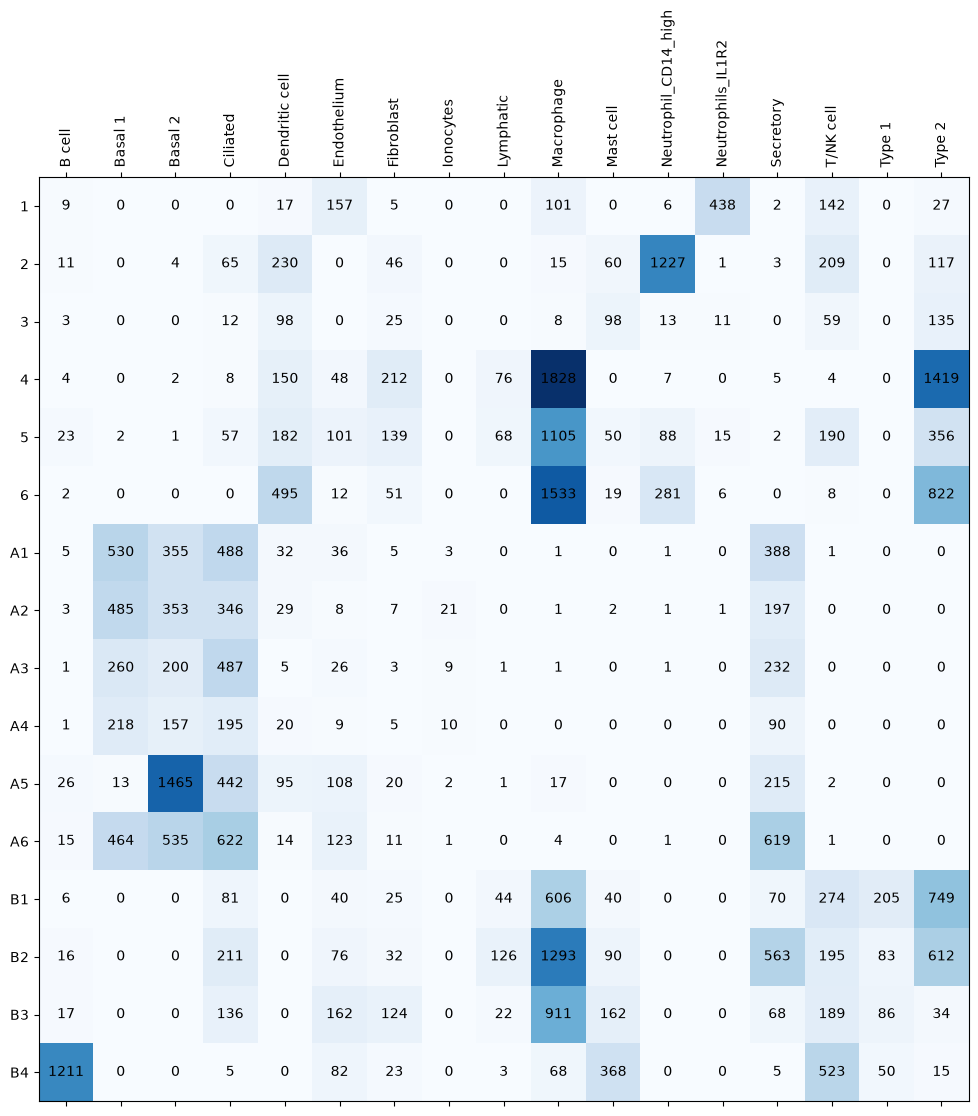

In [32]:
from matplotlib import pyplot as plt
import numpy as np

batch_types = anndata.obs.groupby(["batch", "cell_type"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 12))
plt.matshow(batch_types, cmap="Blues", aspect="auto", fignum=0)
for (i, j), val in np.ndenumerate(batch_types.values):
    plt.text(j, i, val, ha='center', va='center', color='black')
plt.xticks(range(len(batch_types.columns)), batch_types.columns, rotation=90)
plt.yticks(range(len(batch_types.index)), batch_types.index)
plt.show()